# Instruction summarization

In [3]:
import utils, json
utils.load_env_vars()
from llms import generate

summarization_prompt = """You are given an instruction below. Your goal is to summarize the plot of the instruction into 30 words. Do not summarize anything about author style, just summarize the plot.

Instruction:
[[INSTRUCTION]]

Now output the summary of the instruction in the instruction, nothing else. Do not exceed 30 words.
"""

import os
def extract_instruction_set(use_short_summary=True):
    instructions = []
    for fn in os.listdir("data/writing_prompts_analysis/"):
        with open(os.path.join("data/writing_prompts_analysis/", fn), "r") as f:
            prompt = f.read()

        all_lines = prompt.split("\n")
        line_idxs = [i for i, line in enumerate(all_lines) if "==============" in line]
        second_part = "\n".join(all_lines[line_idxs[-1]+1:])
        lines = second_part.split("\n")
        instruction_text = "\n".join(lines[1:])
        instruction = {"instruction_id": fn.replace(".txt", "").replace(" ", "_")}
        if use_short_summary:
            summary = generate([{"role": "user", "content": summarization_prompt}], model="gpt-4o", max_tokens=4000, variables={"INSTRUCTION": instruction_text})
            # print(summary)
            instruction["instruction"] = summary
            instruction["full_instruction"] = instruction_text
            # instructions.append({"instruction_id": fn.replace(".txt", "").replace(" ", "_"), "full_instruction": instruction, "instruction": summary, "responses": []})
        else:
            instruction["instruction"] = instruction_text
            instruction["full_instruction"] = instruction_text
        instruction["responses"] = []
        instructions.append(instruction)

    return instructions

dataset_fn = "data/reward_calibration_data.json"
instructions = extract_instruction_set(use_short_summary=False)
with open(dataset_fn, "w") as f:
    json.dump(instructions, f, indent=4)


# Extract Human-written responses

In [4]:
import json

dataset_fn = "data/reward_calibration_data.json"
with open(dataset_fn, "r") as f:
    instructions = json.load(f)

id2instruction = {instruction["instruction_id"]: instruction for instruction in instructions}

with open("data/expert_vs_MFA.json", "r") as f:
    data = json.load(f)

for d in data:
    d["expert_name"] = d["expert_name"].replace(" ", "_")

    instruction = id2instruction[d["expert_name"]]
    instruction["responses"].append({"origin": "expert", "response": d["expert"]})
    instruction["responses"].append({"origin": "MFA", "response": d["MFA"]})

with open(dataset_fn, "w") as f:
    json.dump(instructions, f, indent=4)


# Amateur Response Scoring

In [17]:
from model_mbert2 import MBertWritingReward
import json

with open("data/amateur_writing.txt", "r") as f:
    amateur_writing = f.read()


reward_model = MBertWritingReward("models/mbert2-large-PR-final")

stories = amateur_writing.split("================================================================================================================================")
stories = [story.strip() for story in stories if story.strip()]
print(len(stories))
print([len(story) for story in stories])

amateur_responses = []
for story in stories:
    score = reward_model.predict_regression(story)
    amateur_responses.append({"origin": "amateur", "response": story, "score": score})


with open("data/amateur_responses.json", "w") as f:
    json.dump(amateur_responses, f, indent=4)


50
[1886, 3008, 2176, 1505, 1897, 2558, 2692, 1579, 2529, 2340, 2250, 1949, 2169, 2938, 3129, 2472, 3064, 2626, 3284, 1761, 3316, 3866, 2856, 4026, 2610, 2307, 4018, 3510, 3558, 2889, 2941, 4001, 2569, 3927, 4248, 4625, 3557, 6287, 5173, 5699, 4906, 4689, 2975, 9126, 2744, 4832, 1849, 4802, 2910, 4988]


# Generate responses with LLM

In [4]:

import json

with open("data/reward_calibration_data_short_summary.json", "r") as f:
    instructions = json.load(f)

# remove all these model keys:
model_keys = ["gpt-3.5-turbo", "gpt-4o-mini", "gpt-4o", "gpt-4.5-preview", "claude3.7-sonnet", "claude3.5-sonnet", "claude3-haiku", "gemini-1.5-flash", "gemini-1.5-pro", "gemini-2.0-flash", "gemini-2.5-pro-exp-03-25"]
for instruction in instructions:
    instruction["responses"] = [response for response in instruction["responses"] if response["origin"] not in model_keys]

with open("data/reward_calibration_data_short_summary.json", "w") as f:
    json.dump(instructions, f, indent=4)



In [ ]:
import utils, time

utils.load_env_vars()

from llms import generate
import json, tqdm

dataset_fn = "data/reward_calibration_data_short_summary.json"
# dataset_fn = "data/reward_calibration_data.json"
with open(dataset_fn, "r") as f:
    instructions = json.load(f)

max_tokens = {"gpt-3.5-turbo": 1000}

for model in ["gpt-3.5-turbo", "gpt-4o-mini", "gpt-4o", "gpt-4.5-preview", "claude3.7-sonnet", "claude3.5-sonnet", "claude3-haiku", "gemini-1.5-flash", "gemini-1.5-pro", "gemini-2.0-flash", "gemini-2.5-pro-exp-03-25"]: # , "o1"
    for instruction in tqdm.tqdm_notebook(instructions, desc=f"Generating {model} responses"):
        if any([response["origin"] == model for response in instruction["responses"]]):
            continue
        extra_params = {"timeout": 1200} if "gpt" in model else {}

        instruction_text = instruction["instruction"]
        if "short" in dataset_fn:
            instruction_text += "\n\nNow write a 400 word paragraph about the content above. Do not add any other text, just generate the writing sample. Be original, and avoid cliches."
        response = generate([{"role": "user", "content": instruction_text}], model=model, max_tokens=max_tokens.get(model, 4000), **extra_params)
        instruction["responses"].append({"origin": model, "response": response})

        with open(dataset_fn, "w") as f:
            json.dump(instructions, f, indent=4)

        if model == "gemini-2.5-pro":
            time.sleep(12.5)


/tmp/ipykernel_631438/2063761362.py:16: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for instruction in tqdm.tqdm_notebook(instructions, desc=f"Generating {model} responses"):


Generating gpt-3.5-turbo responses:   0%|          | 0/50 [00:00<?, ?it/s]

# Compute rewards

In [3]:
from model_mbert2 import MBertWritingReward
import json, tqdm

# reward_model, pred_key = MBertWritingReward("models/mbert2-large-PR-final"), "score"
# reward_model, pred_key = MBertWritingReward("models/mbert2-large-PRE-loss0.537"), "score_pre"
reward_model, pred_key = MBertWritingReward("models/WQRM-w-exp"), "score_pre"

for dataset_fn in ["data/reward_calibration_data_short_summary.json", "data/reward_calibration_data.json"]:

    with open(dataset_fn, "r") as f:
        instructions = json.load(f)

    todos = [r for instruction in instructions for r in instruction["responses"] if pred_key not in r]
    # todos = [r for instruction in instructions for r in instruction["responses"]] # force refresh

    print(len(todos))
    for response in tqdm.tqdm_notebook(todos, desc=f"Predicting {pred_key}"):
        response[pred_key] = reward_model.predict_regression(response["response"])

    with open(dataset_fn, "w") as f:
        json.dump(instructions, f, indent=4)


582


/tmp/ipykernel_885876/1698538570.py:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for response in tqdm.tqdm_notebook(todos, desc=f"Predicting {pred_key}"):


Predicting score_pre:   0%|          | 0/582 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0


/tmp/ipykernel_885876/1698538570.py:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for response in tqdm.tqdm_notebook(todos, desc=f"Predicting {pred_key}"):


Predicting score_pre: 0it [00:00, ?it/s]

# Analyze Results

In [17]:
import json, numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd

clean_names = {"gpt-4o": "GPT-4o", "gpt-4o-mini": "GPT-4o-mini", "gpt-3.5-turbo": "GPT-3.5-turbo", "amateur": "Amateur Writer", "MFA": "MFA Student", "expert": "Award-winning Author", "gpt-4.5-preview": "GPT-4.5-preview", "claude3-haiku": "Claude 3 Haiku", "claude3.5-sonnet": "Claude 3.5 Sonnet", "claude3.7-sonnet": "Claude 3.7 Sonnet", "gemini-1.5-flash": "Gemini 1.5 Flash", "gemini-1.5-pro": "Gemini 1.5 Pro", "gemini-2.0-flash": "Gemini 2.0 Flash", "gemini-2.5-pro-exp-03-25": "Gemini 2.5 Pro", "gemini-2.5-pro": "Gemini 2.5 Pro"}
pred_key = "score_pre"

def create_palette():
    color_human_pure = np.array([230, 22, 112])
    color_oai_pure = np.array([0, 195, 158])
    grey = np.array([200, 200, 200])
    color_map = {}
    oai_models = ["gpt-3.5-turbo", "gpt-4o-mini", "gpt-4o", "gpt-4.5-preview"]
    for i, model in enumerate(oai_models):
        frac = ((i+1) / (len(oai_models)))
        color_map[model] = (frac * color_oai_pure + (1 - frac) * grey) / 255

    # dark orange
    color_anthropic_pure = np.array([255, 140, 0])
    anthropic_models = ["claude3-haiku", "claude3.5-sonnet", "claude3.7-sonnet"]
    for i, model in enumerate(anthropic_models):
        frac = ((i+1) / (len(anthropic_models)))
        color_map[model] = (frac * color_anthropic_pure + (1 - frac) * grey) / 255

    # dark blue
    color_google_pure = np.array([0, 140, 255])
    google_models = ["gemini-1.5-flash", "gemini-1.5-pro", "gemini-2.0-flash", "gemini-2.5-pro"]
    for i, model in enumerate(google_models):
        frac = ((i+1) / (len(google_models)))
        color_map[model] = (frac * color_google_pure + (1 - frac) * grey) / 255

    human_writers = ["amateur", "MFA", "expert"]
    for i, writer in enumerate(human_writers):
        frac = ((i+1) / (len(human_writers)))
        color_map[writer] = (frac * color_human_pure + (1 - frac) * grey) / 255

    palette = {clean_names[origin]: tuple(color_map[origin]) for origin in origins}
    origin_order = human_writers[1:][::-1] + oai_models[::-1] + anthropic_models[::-1] + google_models[::-1]
    origin_order = [clean_names[origin] for origin in origin_order]
    return palette, origin_order

In [14]:
import json, numpy as np

dataset_fn = "data/reward_calibration_data.json"
with open(dataset_fn, "r") as f:
    instructions = json.load(f)
instruct_lengths = []
for d in instructions:
    lines = d["instruction"].split("\n")
    lines = [line.strip() for line in lines if line.strip()]
    instruct = lines[1]
    instruct_lengths.append(len(instruct.split()))

print(np.mean(instruct_lengths))

dataset_fn = "data/reward_calibration_data_short_summary.json"
with open(dataset_fn, "r") as f:
    instructions = json.load(f)

instruct_lengths = []
for d in instructions:
    instruct = d["instruction"]
    # print("---")
    # print(instruct)
    instruct_lengths.append(len(instruct.split()))

print(np.mean(instruct_lengths))
    

180.44
27.34


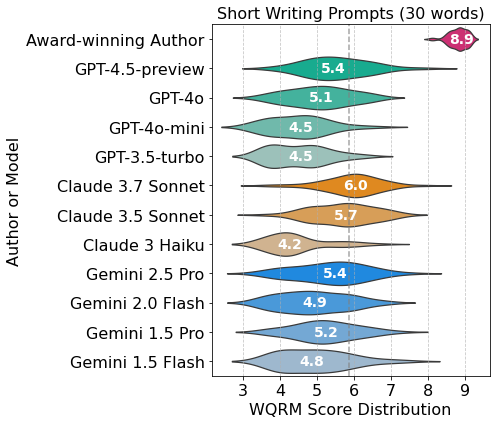

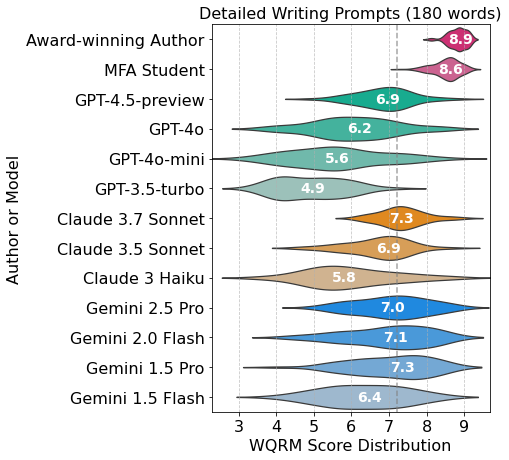

In [19]:
from collections import Counter
import json, numpy as np

for dataset_fn in ["data/reward_calibration_data_short_summary.json", "data/reward_calibration_data.json"]:

    with open(dataset_fn, "r") as f:
        instructions = json.load(f)

    # pred_key = "score"
    pred_key = "score_pre"

    origins = list(set([response["origin"] for instruction in instructions for response in instruction["responses"]])) #+ ["amateur"]

    all_responses = [response for instruction in instructions for response in instruction["responses"] if not ("MFA" in response["origin"] and "short" in dataset_fn)]

    origin2scores = {origin: [] for origin in origins}
    for response in all_responses:
        origin2scores[response["origin"]].append(response[pred_key])

    palette, origin_order = create_palette()

    if "short" in dataset_fn:
        origins = [origin for origin in origins if "MFA" not in origin]
        origin_order = [origin for origin in origin_order if "MFA" not in origin]
    df = pd.DataFrame([{"Origin": clean_names[response["origin"]], "Score": response[pred_key]} for response in all_responses])

    for type in ["violin"]:
        plt.figure(figsize=(7, max(5, len(origins) * 0.5)))
        if type == "violin":
            ax = sns.violinplot(x="Score", y="Origin", data=df, order=origin_order, orient="h", palette=palette, hue="Origin", inner=None)
        else:
            ax = sns.boxplot(x="Score", y="Origin", data=df, order=origin_order, orient="h", palette=palette, hue="Origin")
        for origin in origin_order:
            median_score = df[df["Origin"] == origin]["Score"].median()
            mean_score = df[df["Origin"] == origin]["Score"].mean()
            if type == "box":
                ax.text(median_score+0.05, origin, f"{median_score:.1f}", ha="left", va="center", fontsize=12, color="black", fontweight="bold")
            else:
                ax.text(median_score+0.05, origin, f"{median_score:.1f}", ha="center", va="center", fontsize=14, color="white", fontweight="bold")

        plt.axvline(x=df["Score"].mean(), color='gray', linestyle='--', alpha=0.7)

        plt.xlabel("WQRM Score Distribution", fontsize=16)
        plt.xticks(fontsize=16)
        plt.ylabel("Author or Model", fontsize=16)
        plt.yticks(fontsize=16)
        plt.xlim(min(df["Score"]) - 1.0, max(df["Score"]) + 0.5)  # Add some padding
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.title("Detailed Writing Prompts (180 words)" if dataset_fn == "data/reward_calibration_data.json" else "Short Writing Prompts (30 words)", fontsize=16)
        name = "short" if dataset_fn == "data/reward_calibration_data_short_summary.json" else "detailed"
        plt.tight_layout()
        plt.savefig(f"plots/reward_calibration_{type}_{name}.pdf")
        plt.show()


# SubEdits Calibration

In [9]:
from model_mbert2 import MBertWritingReward
from utils_subdatasets import generate_subdatasets
import json, numpy as np

reward_model = MBertWritingReward("models/mbert2-large-PR-final")

with open("data/LAMP-train-val-test.json", "r") as f:
    data = json.load(f)

LAMP_test = [d for d in data if d["data-split"] == "test"]
LAMP_test = [d for d in LAMP_test if len(d["fine_grained_edits"]) >= 7] # only keep triplets with at least 7 edits
print(len(LAMP_test))

N_keeps = [0, 1, 2, 3, 4, 5, 6, 7]
subdatasets = generate_subdatasets(LAMP_test, N_keeps=N_keeps)

all_scores = {N_keep: [] for N_keep in N_keeps}
for N_keep, samples in zip(N_keeps, subdatasets.values()):
    print(N_keep, len(samples))
    for sample in samples:
        response = sample["paragraph1"] if sample["reference_preference"] == "1" else sample["paragraph2"]
        all_scores[N_keep].append(reward_model.predict_regression(response))

for N_keep in N_keeps:
    print(N_keep, np.mean(all_scores[N_keep]), np.std(all_scores[N_keep]))

138
0 138
1 138
2 138
3 138
4 138
5 138
6 138
7 138
0 4.5063765187194385 0.9241551071527923
1 4.641421278317769 0.9286691977527847
2 4.807457348574763 0.9276777893149033
3 5.012028336524963 0.9626164886360729
4 5.1788719305093736 0.9814134384141785
5 5.288761220116546 0.9261689076529271
6 5.484679178915162 0.9597250054157945
7 5.713260913240736 0.9732389768867619


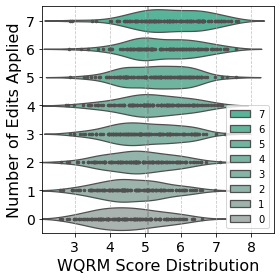

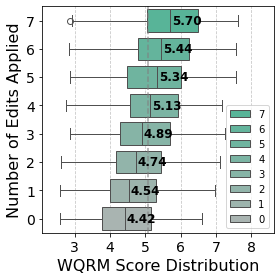

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

color_oai_pure = np.array([73, 195, 158])
grey = np.array([180, 180, 180])
palette = {}
for N_keep in N_keeps:
    frac = ((N_keep+1) / (len(N_keeps)))
    palette[N_keep] = tuple((frac * color_oai_pure + (1 - frac) * grey) / 255)

df = pd.DataFrame([{"#Edits": N_keep, "Score": score} for N_keep, scores in all_scores.items() for score in scores])
row_order = df.groupby("#Edits")["Score"].mean().sort_values(ascending=False).index.tolist()

for type in ["violin", "box"]:
    plt.figure(figsize=(4, 4))
    if type == "violin":
        ax = sns.violinplot(x="Score", y="#Edits", data=df, order=row_order, orient="h", palette=palette, inner="point", hue="#Edits")
    else:
        ax = sns.boxplot(x="Score", y="#Edits", data=df, order=row_order, orient="h", palette=palette, hue="#Edits")
        for N_keep in row_order:
            median_score = df[df["#Edits"] == N_keep]["Score"].median()
            mean_score = df[df["#Edits"] == N_keep]["Score"].mean()
            ax.text(median_score+0.05, len(N_keeps)-1-N_keep, f"{median_score:.2f}", ha="left", va="center", fontsize=12, color="black", fontweight="bold")

    plt.axvline(x=df["Score"].mean(), color='gray', linestyle='--', alpha=0.7)

    # plt.title("Score Distribution by Response Origin")
    plt.xlabel("WQRM Score Distribution", fontsize=16)
    plt.xticks(fontsize=14)
    plt.ylabel("Number of Edits Applied", fontsize=16)
    plt.yticks(fontsize=14)
    plt.xlim(min(df["Score"]) - 0.5, max(df["Score"]) + 1.0)  # Add some padding
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1])

    plt.savefig(f"plots/subedit_calibration_{type}.pdf")

    plt.show()

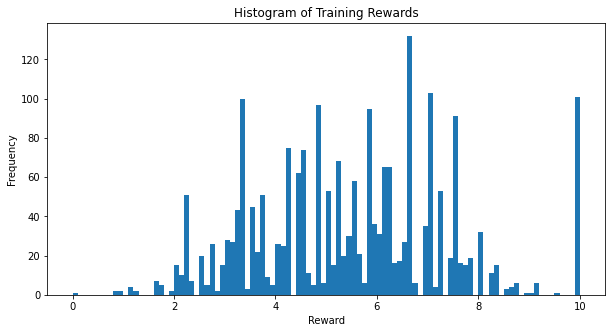

In [7]:
from matplotlib import pyplot as plt    
import json

with open("data/lamp_PRE_train.json", "r") as f:
    data = json.load(f)


training_rewards = []
for d in data:
    if "reference_preference" in d:
        continue
    training_rewards.append(d['zscore'])

# histogram of training rewards
plt.figure(figsize=(10, 5))
plt.hist(training_rewards, bins=100)
plt.title("Histogram of Training Rewards")
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.show()